In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import StandardScaler

In [38]:
df = pd.read_csv("hotel_bookings.csv")
df

,ID,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,arrival_date,stays_in_weekend_nights,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,1,Resort Hotel,0,342,2015,July,27,1,01/07/2015,0,...,No Deposit,NaN,NaN,0,Transient,0,0,0,Check-Out,01/07/2015
1,2,Resort Hotel,0,737,2015,July,27,1,01/07/2015,0,...,No Deposit,NaN,NaN,0,Transient,0,0,0,Check-Out,01/07/2015
2,3,Resort Hotel,0,7,2015,July,27,1,01/07/2015,0,...,No Deposit,NaN,NaN,0,Transient,75,0,0,Check-Out,02/07/2015
3,4,Resort Hotel,0,13,2015,July,27,1,01/07/2015,0,...,No Deposit,304.0,NaN,0,Transient,75,0,0,Check-Out,02/07/2015
4,5,Resort Hotel,0,14,2015,July,27,1,01/07/2015,0,...,No Deposit,240.0,NaN,0,Transient,98,0,1,Check-Out,03/07/2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119381,119386,City Hotel,0,23,2017,August,35,30,30/08/2017,2,...,No Deposit,394.0,NaN,0,Transient,9614,0,0,Check-Out,06/09/2017
119382,119387,City Hotel,0,102,2017,August,35,31,31/08/2017,2,...,No Deposit,9.0,NaN,0,Transient,22543,0,2,Check-Out,07/09/2017
119383,119388,City Hotel,0,34,2017,August,35,31,31/08/2017,2,...,No Deposit,9.0,NaN,0,Transient,15771,0,4,Check-Out,07/09/2017
119384,119389,City Hotel,0,109,2017,August,35,31,31/08/2017,2,...,No Deposit,89.0,NaN,0,Transient,1044,0,0,Check-Out,07/09/2017


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119386 entries, 0 to 119385
Data columns (total 35 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              119386 non-null  int64  
 1   hotel                           119386 non-null  object 
 2   is_canceled                     119386 non-null  int64  
 3   lead_time                       119386 non-null  int64  
 4   arrival_date_year               119386 non-null  int64  
 5   arrival_date_month              119386 non-null  object 
 6   arrival_date_week_number        119386 non-null  int64  
 7   arrival_date_day_of_month       119386 non-null  int64  
 8   arrival_date                    76373 non-null   object 
 9   stays_in_weekend_nights         119386 non-null  int64  
 10  stays_in_week_nights            119386 non-null  int64  
 11  adults                          119386 non-null  int64  
 12  children        

In [40]:
df['reservation_status_date']=pd.to_datetime(df['reservation_status_date'],format="%d/%m/%Y")
df['reservation_day'] = df['reservation_status_date'].dt.day
df['reservation_month'] = df['reservation_status_date'].dt.month
df['reservation_year'] = df['reservation_status_date'].dt.year
df['reservation_weekday'] = df['reservation_status_date'].dt.weekday
df.head()

,ID,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,arrival_date,stays_in_weekend_nights,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,reservation_day,reservation_month,reservation_year,reservation_weekday
0,1,Resort Hotel,0,342,2015,July,27,1,01/07/2015,0,...,Transient,0,0,0,Check-Out,2015-07-01,1,7,2015,2
1,2,Resort Hotel,0,737,2015,July,27,1,01/07/2015,0,...,Transient,0,0,0,Check-Out,2015-07-01,1,7,2015,2
2,3,Resort Hotel,0,7,2015,July,27,1,01/07/2015,0,...,Transient,75,0,0,Check-Out,2015-07-02,2,7,2015,3
3,4,Resort Hotel,0,13,2015,July,27,1,01/07/2015,0,...,Transient,75,0,0,Check-Out,2015-07-02,2,7,2015,3
4,5,Resort Hotel,0,14,2015,July,27,1,01/07/2015,0,...,Transient,98,0,1,Check-Out,2015-07-03,3,7,2015,4


In [41]:
df['arrival_date']=pd.to_datetime(df['arrival_date'],format="%d/%m/%Y")
df['arrival_day'] = df['arrival_date'].dt.day.astype('Int64')
df['arrival_month'] = df['arrival_date'].dt.month.astype('Int64')
df['arrival_year'] = df['arrival_date'].dt.year.astype('Int64')
df['arrival_weekday'] = df['arrival_date'].dt.weekday.astype('Int64')
df.head()

,ID,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,arrival_date,stays_in_weekend_nights,...,reservation_status,reservation_status_date,reservation_day,reservation_month,reservation_year,reservation_weekday,arrival_day,arrival_month,arrival_year,arrival_weekday
0,1,Resort Hotel,0,342,2015,July,27,1,2015-07-01,0,...,Check-Out,2015-07-01,1,7,2015,2,1,7,2015,2
1,2,Resort Hotel,0,737,2015,July,27,1,2015-07-01,0,...,Check-Out,2015-07-01,1,7,2015,2,1,7,2015,2
2,3,Resort Hotel,0,7,2015,July,27,1,2015-07-01,0,...,Check-Out,2015-07-02,2,7,2015,3,1,7,2015,2
3,4,Resort Hotel,0,13,2015,July,27,1,2015-07-01,0,...,Check-Out,2015-07-02,2,7,2015,3,1,7,2015,2
4,5,Resort Hotel,0,14,2015,July,27,1,2015-07-01,0,...,Check-Out,2015-07-03,3,7,2015,4,1,7,2015,2


In [42]:
hotel_dummies = pd.get_dummies(df['hotel'])
df = pd.concat([df, hotel_dummies], axis=1)
df

,ID,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,arrival_date,stays_in_weekend_nights,...,reservation_day,reservation_month,reservation_year,reservation_weekday,arrival_day,arrival_month,arrival_year,arrival_weekday,City Hotel,Resort Hotel
0,1,Resort Hotel,0,342,2015,July,27,1,2015-07-01,0,...,1,7,2015,2,1,7,2015,2,False,True
1,2,Resort Hotel,0,737,2015,July,27,1,2015-07-01,0,...,1,7,2015,2,1,7,2015,2,False,True
2,3,Resort Hotel,0,7,2015,July,27,1,2015-07-01,0,...,2,7,2015,3,1,7,2015,2,False,True
3,4,Resort Hotel,0,13,2015,July,27,1,2015-07-01,0,...,2,7,2015,3,1,7,2015,2,False,True
4,5,Resort Hotel,0,14,2015,July,27,1,2015-07-01,0,...,3,7,2015,4,1,7,2015,2,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119381,119386,City Hotel,0,23,2017,August,35,30,2017-08-30,2,...,6,9,2017,2,30,8,2017,2,True,False
119382,119387,City Hotel,0,102,2017,August,35,31,2017-08-31,2,...,7,9,2017,3,31,8,2017,3,True,False
119383,119388,City Hotel,0,34,2017,August,35,31,2017-08-31,2,...,7,9,2017,3,31,8,2017,3,True,False
119384,119389,City Hotel,0,109,2017,August,35,31,2017-08-31,2,...,7,9,2017,3,31,8,2017,3,True,False


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119386 entries, 0 to 119385
Data columns (total 45 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   ID                              119386 non-null  int64         
 1   hotel                           119386 non-null  object        
 2   is_canceled                     119386 non-null  int64         
 3   lead_time                       119386 non-null  int64         
 4   arrival_date_year               119386 non-null  int64         
 5   arrival_date_month              119386 non-null  object        
 6   arrival_date_week_number        119386 non-null  int64         
 7   arrival_date_day_of_month       119386 non-null  int64         
 8   arrival_date                    76373 non-null   datetime64[ns]
 9   stays_in_weekend_nights         119386 non-null  int64         
 10  stays_in_week_nights            119386 non-null  int64  

In [44]:
deposit_dummies = pd.get_dummies(df['deposit_type'], drop_first=False)[['Non Refund', 'Refundable']]
df = pd.concat([df, deposit_dummies], axis=1)
df

,ID,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,arrival_date,stays_in_weekend_nights,...,reservation_year,reservation_weekday,arrival_day,arrival_month,arrival_year,arrival_weekday,City Hotel,Resort Hotel,Non Refund,Refundable
0,1,Resort Hotel,0,342,2015,July,27,1,2015-07-01,0,...,2015,2,1,7,2015,2,False,True,False,False
1,2,Resort Hotel,0,737,2015,July,27,1,2015-07-01,0,...,2015,2,1,7,2015,2,False,True,False,False
2,3,Resort Hotel,0,7,2015,July,27,1,2015-07-01,0,...,2015,3,1,7,2015,2,False,True,False,False
3,4,Resort Hotel,0,13,2015,July,27,1,2015-07-01,0,...,2015,3,1,7,2015,2,False,True,False,False
4,5,Resort Hotel,0,14,2015,July,27,1,2015-07-01,0,...,2015,4,1,7,2015,2,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119381,119386,City Hotel,0,23,2017,August,35,30,2017-08-30,2,...,2017,2,30,8,2017,2,True,False,False,False
119382,119387,City Hotel,0,102,2017,August,35,31,2017-08-31,2,...,2017,3,31,8,2017,3,True,False,False,False
119383,119388,City Hotel,0,34,2017,August,35,31,2017-08-31,2,...,2017,3,31,8,2017,3,True,False,False,False
119384,119389,City Hotel,0,109,2017,August,35,31,2017-08-31,2,...,2017,3,31,8,2017,3,True,False,False,False


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119386 entries, 0 to 119385
Data columns (total 47 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   ID                              119386 non-null  int64         
 1   hotel                           119386 non-null  object        
 2   is_canceled                     119386 non-null  int64         
 3   lead_time                       119386 non-null  int64         
 4   arrival_date_year               119386 non-null  int64         
 5   arrival_date_month              119386 non-null  object        
 6   arrival_date_week_number        119386 non-null  int64         
 7   arrival_date_day_of_month       119386 non-null  int64         
 8   arrival_date                    76373 non-null   datetime64[ns]
 9   stays_in_weekend_nights         119386 non-null  int64         
 10  stays_in_week_nights            119386 non-null  int64  

In [46]:
market_segment_dummies = pd.get_dummies(df['market_segment'])
df = pd.concat([df, market_segment_dummies], axis=1)
df

,ID,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,arrival_date,stays_in_weekend_nights,...,Resort Hotel,Non Refund,Refundable,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA
0,1,Resort Hotel,0,342,2015,July,27,1,2015-07-01,0,...,True,False,False,False,False,False,True,False,False,False
1,2,Resort Hotel,0,737,2015,July,27,1,2015-07-01,0,...,True,False,False,False,False,False,True,False,False,False
2,3,Resort Hotel,0,7,2015,July,27,1,2015-07-01,0,...,True,False,False,False,False,False,True,False,False,False
3,4,Resort Hotel,0,13,2015,July,27,1,2015-07-01,0,...,True,False,False,False,False,True,False,False,False,False
4,5,Resort Hotel,0,14,2015,July,27,1,2015-07-01,0,...,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119381,119386,City Hotel,0,23,2017,August,35,30,2017-08-30,2,...,False,False,False,False,False,False,False,False,True,False
119382,119387,City Hotel,0,102,2017,August,35,31,2017-08-31,2,...,False,False,False,False,False,False,False,False,False,True
119383,119388,City Hotel,0,34,2017,August,35,31,2017-08-31,2,...,False,False,False,False,False,False,False,False,False,True
119384,119389,City Hotel,0,109,2017,August,35,31,2017-08-31,2,...,False,False,False,False,False,False,False,False,False,True


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119386 entries, 0 to 119385
Data columns (total 54 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   ID                              119386 non-null  int64         
 1   hotel                           119386 non-null  object        
 2   is_canceled                     119386 non-null  int64         
 3   lead_time                       119386 non-null  int64         
 4   arrival_date_year               119386 non-null  int64         
 5   arrival_date_month              119386 non-null  object        
 6   arrival_date_week_number        119386 non-null  int64         
 7   arrival_date_day_of_month       119386 non-null  int64         
 8   arrival_date                    76373 non-null   datetime64[ns]
 9   stays_in_weekend_nights         119386 non-null  int64         
 10  stays_in_week_nights            119386 non-null  int64  

In [48]:
corr = df.corr(numeric_only=True)['is_canceled'].sort_values(ascending=False)

print(corr)

is_canceled                       1.000000
Non Refund                        0.481488
lead_time                         0.293177
Groups                            0.221886
City Hotel                        0.136505
previous_cancellations            0.110140
adults                            0.059990
days_in_waiting_list              0.054193
stays_in_week_nights              0.024771
arrival_date_year                 0.016732
arrival_day                       0.016337
arrival_weekday                   0.016146
arrival_date_week_number          0.008132
children                          0.005048
stays_in_weekend_nights          -0.001783
total_kids                       -0.002797
arrival_year                     -0.003096
arrival_date_day_of_month        -0.006084
Online TA                        -0.006269
Refundable                       -0.011310
Aviation                         -0.013944
company                          -0.020642
Offline TA/TO                    -0.028451
arrival_mon

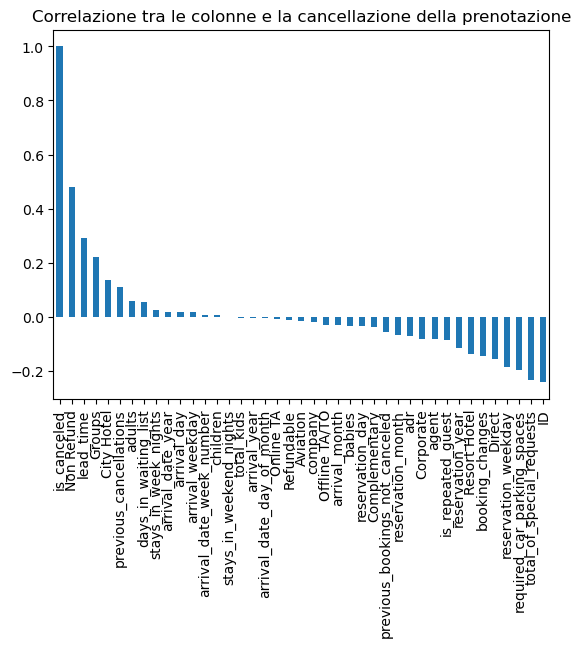

In [49]:
corr.plot(kind='bar')
plt.title("Correlazione tra le colonne e la cancellazione della prenotazione")
plt.show()

In [50]:
df2=df[[
    'is_canceled',
    'Non Refund',
    'lead_time',
    'previous_cancellations',
    'Refundable',
    'total_of_special_requests',
    'required_car_parking_spaces',
    'reservation_weekday',
    'booking_changes',
    'is_repeated_guest',
    'City Hotel',
    'Groups',
    'Offline TA/TO',
    'Aviation',
    'Corporate',
    'Direct',
    'Complementary',
]]
df2

,is_canceled,Non Refund,lead_time,previous_cancellations,Refundable,total_of_special_requests,required_car_parking_spaces,reservation_weekday,booking_changes,is_repeated_guest,City Hotel,Groups,Offline TA/TO,Aviation,Corporate,Direct,Complementary
0,0,False,342,0,False,0,0,2,3,0,False,False,False,False,False,True,False
1,0,False,737,0,False,0,0,2,4,0,False,False,False,False,False,True,False
2,0,False,7,0,False,0,0,3,0,0,False,False,False,False,False,True,False
3,0,False,13,0,False,0,0,3,0,0,False,False,False,False,True,False,False
4,0,False,14,0,False,1,0,4,0,0,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119381,0,False,23,0,False,0,0,2,0,0,True,False,True,False,False,False,False
119382,0,False,102,0,False,2,0,3,0,0,True,False,False,False,False,False,False
119383,0,False,34,0,False,4,0,3,0,0,True,False,False,False,False,False,False
119384,0,False,109,0,False,0,0,3,0,0,True,False,False,False,False,False,False


In [51]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119386 entries, 0 to 119385
Data columns (total 17 columns):
 #   Column                       Non-Null Count   Dtype
---  ------                       --------------   -----
 0   is_canceled                  119386 non-null  int64
 1   Non Refund                   119386 non-null  bool 
 2   lead_time                    119386 non-null  int64
 3   previous_cancellations       119386 non-null  int64
 4   Refundable                   119386 non-null  bool 
 5   total_of_special_requests    119386 non-null  int64
 6   required_car_parking_spaces  119386 non-null  int64
 7   reservation_weekday          119386 non-null  int32
 8   booking_changes              119386 non-null  int64
 9   is_repeated_guest            119386 non-null  int64
 10  City Hotel                   119386 non-null  bool 
 11  Groups                       119386 non-null  bool 
 12  Offline TA/TO                119386 non-null  bool 
 13  Aviation                     

In [52]:
corr2=df2[[
    'Non Refund',
    'lead_time',
    'previous_cancellations',
    'Refundable',
    'total_of_special_requests',
    'required_car_parking_spaces',
    'reservation_weekday',
    'booking_changes',
    'is_repeated_guest',
    'City Hotel',
    'Groups',
    'Offline TA/TO',
    'Aviation',
    'Corporate',
    'Direct',
    'Complementary',]].corr()
corr2

,Non Refund,lead_time,previous_cancellations,Refundable,total_of_special_requests,required_car_parking_spaces,reservation_weekday,booking_changes,is_repeated_guest,City Hotel,Groups,Offline TA/TO,Aviation,Corporate,Direct,Complementary
Non Refund,1.000000,0.380174,0.143313,-0.013752,-0.268029,-0.094986,-0.149393,-0.119337,-0.058425,0.172014,0.464150,0.130183,-0.016639,-0.038880,-0.126601,-0.029524
lead_time,0.380174,1.000000,0.086040,0.016586,-0.095688,-0.116461,-0.071832,0.000138,-0.124418,0.075405,0.346267,0.146293,-0.041556,-0.165085,-0.174105,-0.067188
previous_cancellations,0.143313,0.086040,1.000000,-0.003803,-0.048382,-0.018493,-0.030030,-0.026994,0.082293,-0.012289,0.098717,0.016282,-0.001704,0.020561,-0.027929,0.012270
Refundable,-0.013752,0.016586,-0.003803,1.000000,-0.019964,0.009157,-0.011744,0.020991,-0.001515,-0.042234,0.063069,-0.016332,-0.001644,-0.003520,-0.008222,-0.002917
total_of_special_requests,-0.268029,-0.095688,-0.048382,-0.019964,1.000000,0.082635,0.059230,0.052844,0.013055,-0.043411,-0.272403,-0.193013,-0.025732,-0.092798,0.002037,0.036071
required_car_parking_spaces,-0.094986,-0.116461,-0.018493,0.009157,0.082635,1.000000,0.039830,0.065617,0.077088,-0.218869,-0.087802,-0.081534,-0.006764,0.043449,0.148117,0.016304
reservation_weekday,-0.149393,-0.071832,-0.030030,-0.011744,0.059230,0.039830,1.000000,0.032714,0.002334,-0.024457,-0.068362,-0.019210,0.001726,0.005650,0.031077,0.009676
booking_changes,-0.119337,0.000138,-0.026994,0.020991,0.052844,0.065617,0.032714,1.000000,0.012090,-0.072813,-0.006380,-0.046192,0.002767,0.028448,0.091997,0.013503
is_repeated_guest,-0.058425,-0.124418,0.082293,-0.001515,0.013055,0.077088,0.002334,0.012090,1.000000,-0.050417,-0.046400,-0.046680,0.060422,0.302075,0.061058,0.125002
City Hotel,0.172014,0.075405,-0.012289,-0.042234,-0.043411,-0.218869,-0.024457,-0.072813,-0.050417,1.000000,0.038699,0.028881,0.031694,-0.045862,-0.131811,0.010898


In [53]:
corr2[corr2.abs() > 0.8]

,Non Refund,lead_time,previous_cancellations,Refundable,total_of_special_requests,required_car_parking_spaces,reservation_weekday,booking_changes,is_repeated_guest,City Hotel,Groups,Offline TA/TO,Aviation,Corporate,Direct,Complementary
Non Refund,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lead_time,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
previous_cancellations,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Refundable,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_of_special_requests,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
required_car_parking_spaces,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reservation_weekday,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_changes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_repeated_guest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City Hotel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
y=df2['is_canceled']
X=df2[[
    'Non Refund',
    'lead_time',
    'previous_cancellations',
    'Refundable',
    'total_of_special_requests',
    'required_car_parking_spaces',
    'reservation_weekday',
    'booking_changes',
    'is_repeated_guest',
    'City Hotel',
    'Groups',
    'Offline TA/TO',
    'Aviation',
    'Corporate',
    'Direct',
    'Complementary',]]

In [55]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.3, random_state=25)

In [56]:
log_reg=LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [57]:
print('Intercept:', log_reg.intercept_)
print('Coefficients:', log_reg.coef_[0])

Intercept: [0.29483271]
Coefficients: [ 5.64105843e+00  4.19364625e-03  1.74254804e+00 -2.37285950e-01
 -7.15198692e-01 -6.12178287e+00 -1.44817846e-01 -4.01733972e-01
 -1.35767349e+00 -3.67198949e-02 -1.34854099e+00 -1.71954182e+00
 -8.57538318e-01 -1.48330491e+00 -1.17891939e+00 -1.32990249e+00]


In [58]:
y_pred = log_reg.predict(X_test)

In [59]:
cm = metrics.confusion_matrix(y_test, y_pred)
cm

array([[20995,  1626],
       [ 5543,  7652]], dtype=int64)

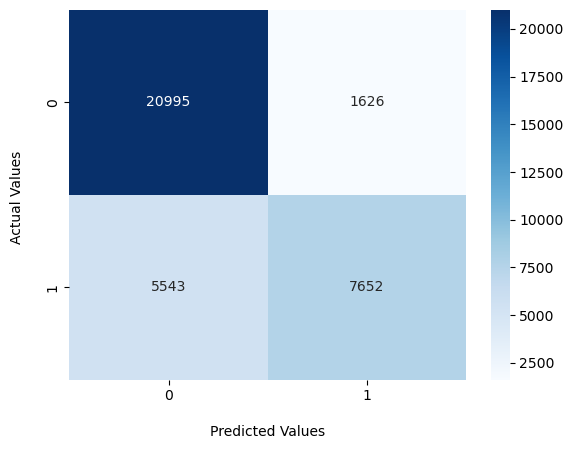

In [60]:
ax= sns.heatmap(cm, annot=True, cmap='Blues',fmt='d')
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values \n')
ax.yaxis.set_ticklabels(['0','1'])
ax.xaxis.set_ticklabels(['0','1'])
plt.show()

In [61]:
# la precision è la metrica migliore perchè voglio essere sicuro che il cliente cancella la prenotazione per vendere la camera
print('Precision score:',metrics.precision_score(y_test, y_pred))
print('Recall score:',metrics.recall_score(y_test, y_pred))
print('Accuracy score:',metrics.accuracy_score(y_test, y_pred))

Precision score: 0.8247467126535891
Recall score: 0.5799166350890489
Accuracy score: 0.7998380612016975


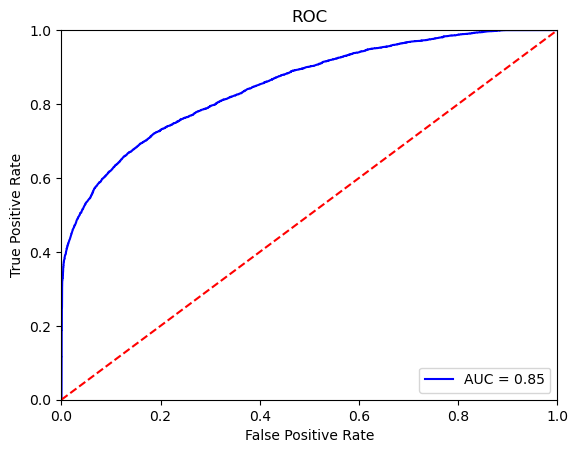

In [64]:
probs= log_reg.predict_proba(X_test)
preds= probs[:,1]
fpr, tpr, threshold=metrics.roc_curve(y_test, preds)
roc_auc = metrics.auc(fpr, tpr)

plt.title('ROC')
plt.plot(fpr, tpr, 'b', label="AUC = %.2f" % roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [62]:
#alzo la soglia di classificazione a 0.65, quindi il mio modello assegna come cencellata (1) la previsione quando è sicuro almeno al 65% che la prenotazione venga cancellata.
#In questo modo si alza la precision e  si abbassa la recall 
y_pred2 = (log_reg.predict_proba(X_test)[:, 1] > 0.65).astype(int)

In [63]:
print('Precision score:',metrics.precision_score(y_test, y_pred2))
print('Recall score:',metrics.recall_score(y_test, y_pred2))
print('Accuracy score:',metrics.accuracy_score(y_test, y_pred2))

Precision score: 0.9466440101954121
Recall score: 0.4222053808260705
Accuracy score: 0.778367210185392
